# 

In [49]:
import os
import numpy as np
import pandas as pd
import pathlib
import imageio

In [50]:
base_dir = '../input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/'

train_pneumonia_dir = base_dir+'train/PNEUMONIA/'
train_normal_dir=base_dir+'train/NORMAL/'

test_pneumonia_dir = base_dir+'test/PNEUMONIA/'
test_normal_dir = base_dir+'test/NORMAL/'

val_normal_dir= base_dir+'val/NORMAL/'
val_pneumonia_dir= base_dir+'val/PNEUMONIA/'

train_pn = [train_pneumonia_dir+"{}".format(i) for i in os.listdir(train_pneumonia_dir) ]
train_normal = [train_normal_dir+"{}".format(i) for i in os.listdir(train_normal_dir) ]

test_normal = [test_normal_dir+"{}".format(i) for i in os.listdir(test_normal_dir)]
test_pn = [test_pneumonia_dir+"{}".format(i) for i in os.listdir(test_pneumonia_dir)]

val_pn= [val_pneumonia_dir+"{}".format(i) for i in os.listdir(val_pneumonia_dir) ]
val_normal= [val_normal_dir+"{}".format(i) for i in os.listdir(val_normal_dir) ]

print ("Total images:",len(train_pn+train_normal+test_normal+test_pn+val_pn+val_normal))
print ("Total pneumonia images:",len(train_pn+test_pn+val_pn))
print ("Total Normal images:",len(train_normal+test_normal+val_normal))

Total images: 5856
Total pneumonia images: 4273
Total Normal images: 1583


In [51]:
#Dataset Preprocessing and Visualisation

#all pneumonia and normal in specific lists
pn = train_pn + test_pn + val_pn
normal = train_normal + test_normal + val_normal

# Spliting dataset in train set,test set and validation set.

train_imgs = pn[:3418]+ normal[:1224]  # 80% of 4273 Pneumonia and normal chest X-ray are 3418 and 1224 respectively.
test_imgs = pn[3418:4059]+ normal[1224:1502]
val_imgs = pn[4059:] + normal[1502:]

print("Total Train Images %s containing %s pneumonia and %s normal images" 
      % (len(train_imgs),len(pn[:3418]),len(normal[:1224])))
print("Total Test Images %s containing %s pneumonia and %s normal images"
      % (len(test_imgs),len(pn[3418:4059]),len(normal[1224:1502])))
print("Total Validation Images %s containing %s pneumonia and %s normal images" 
      % (len(val_imgs),len(pn[4059:]),len(normal[1502:])))

import random

random.shuffle(train_imgs)
random.shuffle(test_imgs)
random.shuffle(val_imgs)

Total Train Images 4642 containing 3418 pneumonia and 1224 normal images
Total Test Images 919 containing 641 pneumonia and 278 normal images
Total Validation Images 295 containing 214 pneumonia and 81 normal images


In [52]:
print(test_imgs[5])

../input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/test/NORMAL/IM-0013-0001.jpeg


In [53]:
#Loading each image into an array and Processing
import cv2
img_size = 224

def preprocess_image(image_list):
    X = [] # images
    y = [] #labels (0 for Normal or 1 for Pneumonia)
    count=0
    for image in image_list:
        try:
            img = cv2.imread(image,cv2.IMREAD_GRAYSCALE)
            img=cv2.resize(img,(img_size,img_size),interpolation=cv2.INTER_CUBIC)
            #convert image to 2D to 3D 
            img = np.dstack([img, img, img])
            #convert greyscale image to RGB
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            # Normalalize Image
            img = img.astype(np.float32)/255.
            count=count+1
            X.append(img) 
        except:
            continue
        #get the labels 
        if 'NORMAL' in image:
            y.append(0)
        elif 'IM' in image:
            y.append(0)
        elif 'virus' or 'bacteria' in image:
            y.append(1)
    return X, y

In [54]:
X, y = preprocess_image(train_imgs)

In [55]:
arr=y	
uniqueValues, occurCount = np.unique(arr, return_counts=True)
 
print("Unique Values : " , uniqueValues)
print("Occurrence Count : ", occurCount)

Unique Values :  [0 1]
Occurrence Count :  [1224 3418]


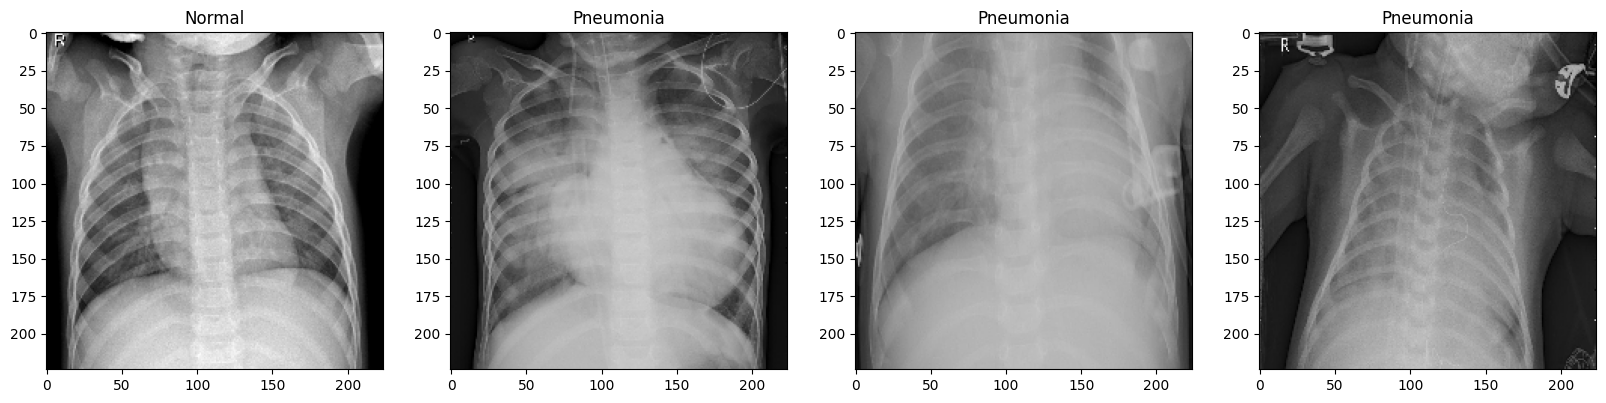

In [56]:
import matplotlib.pyplot as plt 

fig = plt.figure(figsize=(20, 5))
k=1
for i in range(4):
    a = fig.add_subplot(1, 4, k)
    if (y[i]==0):
        a.set_title('Normal')
    else:
        a.set_title('Pneumonia')
        
    plt.imshow(X[i])
    k=k+1;
    

In [57]:
P, t = preprocess_image(test_imgs)

In [58]:
arr=t	
uniqueValues, occurCount = np.unique(arr, return_counts=True)
 
print("Unique Values : " , uniqueValues)
print("Occurrence Count : ", occurCount)

Unique Values :  [0 1]
Occurrence Count :  [278 641]


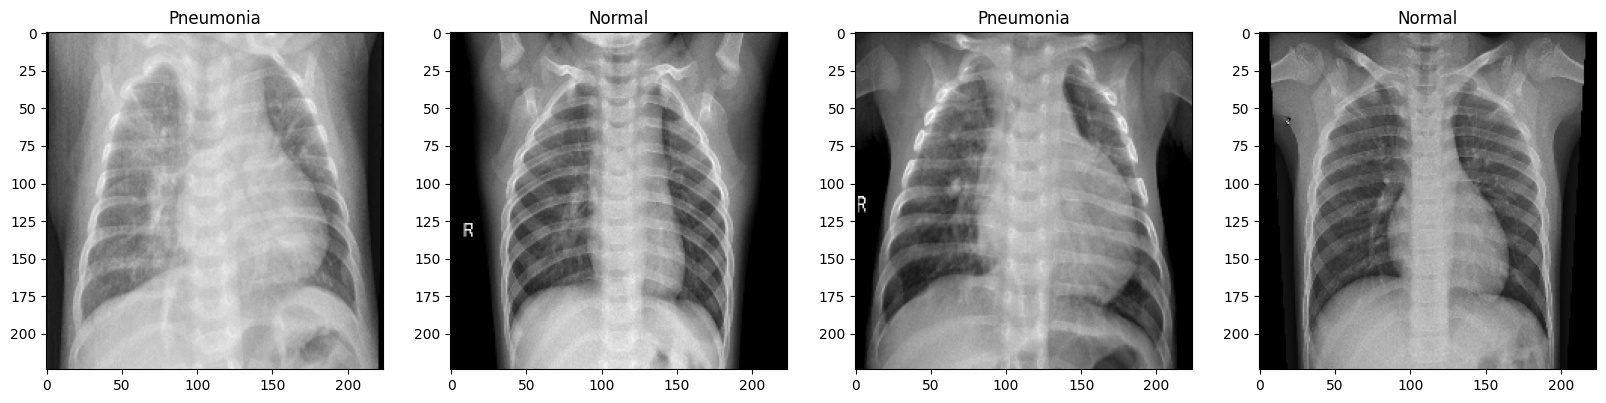

In [59]:
import matplotlib.pyplot as plt 

fig = plt.figure(figsize=(20, 5))
k=1
for i in range(4):
    a = fig.add_subplot(1, 4, k)
    if (t[i]==0):
        a.set_title('Normal')
    else:
        a.set_title('Pneumonia')
        
    plt.imshow(P[i])
    k=k+1;

In [60]:
K, m = preprocess_image(val_imgs)


In [61]:
arr=m

 
# Get a tuple of unique values & their frequency in numpy array
uniqueValues, occurCount = np.unique(arr, return_counts=True)
 
print("Unique Values : " , uniqueValues)
print("Occurrence Count : ", occurCount)

Unique Values :  [0 1]
Occurrence Count :  [ 81 214]


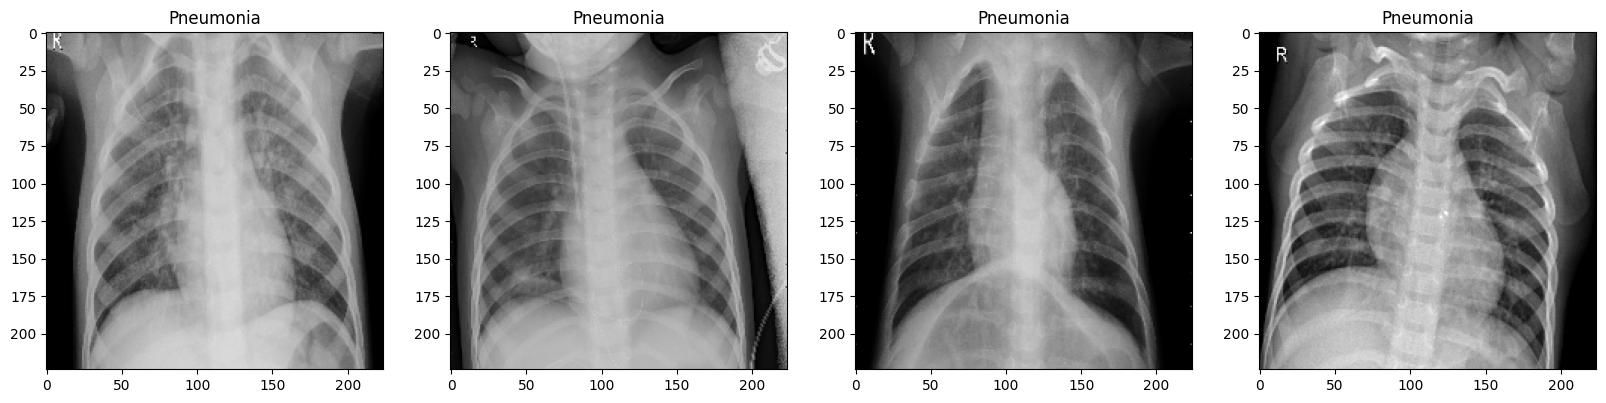

In [62]:
import matplotlib.pyplot as plt 

fig = plt.figure(figsize=(20, 5))
k=1
for i in range(4):
    a = fig.add_subplot(1, 4, k)
    if (m[i]==0):
        a.set_title('Normal')
    else:
        a.set_title('Pneumonia')
        
    plt.imshow(K[i])
    k=k+1;

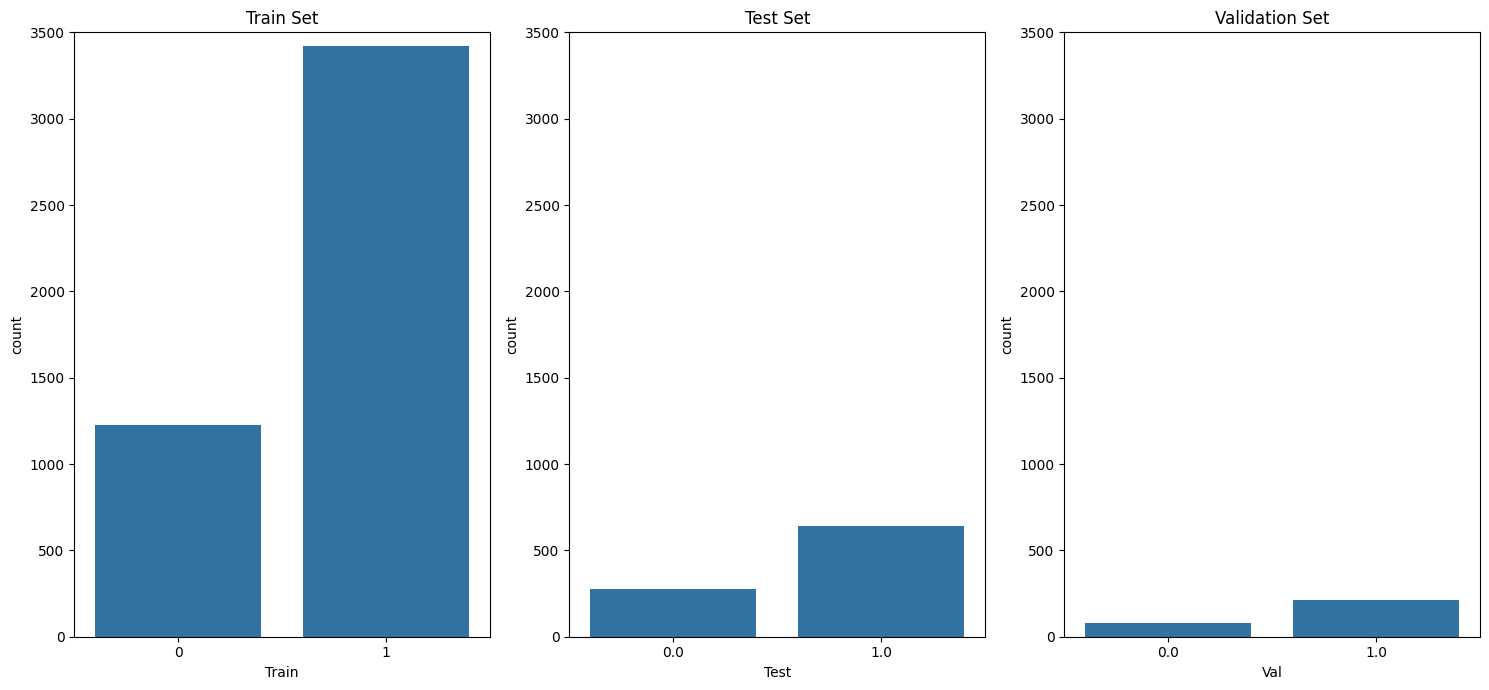

In [63]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame()

df['Train'] = y
df['Test'] = pd.Series(t)
df['Val'] = pd.Series(m)

fig, ax = plt.subplots(1, 3, figsize=(15,7))

# -------------------
# TRAIN
# -------------------

sns.countplot(
    x=df['Train'],
    ax=ax[0]
)

ax[0].set_title("Train Set")

ax[0].set_ylim(0, 3500)

# -------------------
# TEST
# -------------------

sns.countplot(
    x=df['Test'],
    ax=ax[1]
)

ax[1].set_title("Test Set")

ax[1].set_ylim(0, 3500)

# -------------------
# VALIDATION
# -------------------

sns.countplot(
    x=df['Val'],
    ax=ax[2]
)

ax[2].set_title("Validation Set")

ax[2].set_ylim(0, 3500)

plt.tight_layout()

plt.show()

In [64]:
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y),
    y=y
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(1.8962418300653594), 1: np.float64(0.679052077238151)}


In [65]:
import seaborn as sns
import gc

train_imgs = train_pn[:3875]+ train_normal[:1341]
del train_imgs
gc.collect()

X_train = np.array(X)
y_train = np.array(y)
X_test = np.array(P)
y_test = np.array(t)
X_val = np.array(K)
y_val = np.array(m)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)
print(X_val.shape)
print(y_val.shape)

(4642, 224, 224, 3)
(4642,)
(919, 224, 224, 3)
(919,)
(295, 224, 224, 3)
(295,)


In [66]:
# clear memory
del X
del y
gc.collect()

#get the length of the train and validation data
ntrain = len(X_train)
nval = len(X_val)

batch_size = 32

Image Augmentation
Lets build an input pipline for model with the augmentation technique. We artificially increase the dataset with augmentation technique, since we are using a small dataset. It also helps prevent overfitting. Feel free to study various augmentation techniques in internet.

In [67]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rotation_range=7,
    width_shift_range=0.05,
    height_shift_range=0.05,
    shear_range=0.2,
    zoom_range=0.45,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    zoom_range=0.45
)

In [68]:
#Create the image generators
train_generator = train_datagen.flow(X_train, y_train, batch_size=batch_size)
val_generator = val_datagen.flow(X_val, y_val, batch_size=batch_size)

In [69]:
img_size =224

In [70]:
from keras import layers
from keras import models
from keras import optimizers
from keras.applications import *
from keras.layers import Dense, GlobalAveragePooling2D
from keras.preprocessing.image import img_to_array, load_img
from keras.models import Model
from keras import backend as K

# Create the base pre-trained model
# Weights should be none becuase we don't need to train with any pre-trained weights here

base_model = MobileNet(weights=None, include_top=False,input_shape=(img_size, img_size, 3)) 

x = base_model.output

# Add a global spatial average pooling layer
x = GlobalAveragePooling2D()(x)

# Add a logistic layer
predictions = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=predictions)
# Compile model
model.compile(optimizer='adam', loss = 'binary_crossentropy',
                           metrics = ['binary_accuracy', 'mae'])

In [71]:
history = model.fit(

    train_generator,

    steps_per_epoch=ntrain // batch_size,

    epochs=100,

    validation_data=val_generator,

    validation_steps=nval // batch_size,

    class_weight=class_weights

)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 91s 455ms/step - binary_accuracy: 0.7879 - loss: 0.4401 - mae: 0.2439 - val_binary_accuracy: 0.7222 - val_loss: 1.5696 - val_mae: 0.2794
Epoch 2/100
  1/145 ━━━━━━━━━━━━━━━━━━━━ 10s 75ms/step - binary_accuracy: 0.9375 - loss: 0.1340 - mae: 0.1040

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


145/145 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - binary_accuracy: 0.9375 - loss: 0.1340 - mae: 0.1040 - val_binary_accuracy: 0.7257 - val_loss: 1.5589 - val_mae: 0.2759
Epoch 3/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 51s 354ms/step - binary_accuracy: 0.8716 - loss: 0.2941 - mae: 0.1657 - val_binary_accuracy: 0.7292 - val_loss: 2.0386 - val_mae: 0.2711
Epoch 4/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - binary_accuracy: 0.9062 - loss: 0.2840 - mae: 0.1181 - val_binary_accuracy: 0.7257 - val_loss: 2.0695 - val_mae: 0.2745
Epoch 5/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 52s 355ms/step - binary_accuracy: 0.8846 - loss: 0.2735 - mae: 0.1521 - val_binary_accuracy: 0.7222 - val_loss: 1.9374 - val_mae: 0.2782
Epoch 6/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - binary_accuracy: 0.8438 - loss: 0.3593 - mae: 0.1904 - val_binary_accuracy: 0.7292 - val_loss: 1.8856 - val_mae: 0.2713
Epoch 7/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 52s 355ms/step - binary_accuracy: 0.8956 - loss: 0.2407 - mae: 0.1423 - val_binary_accu

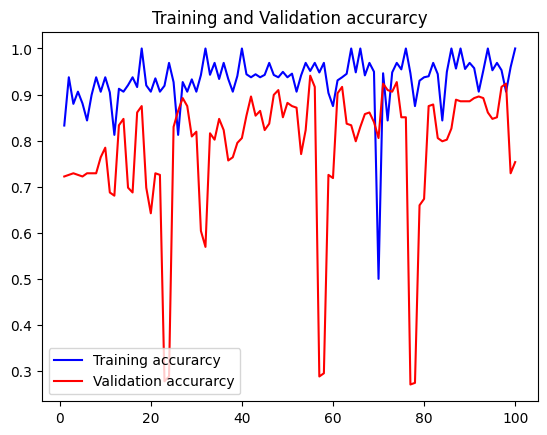

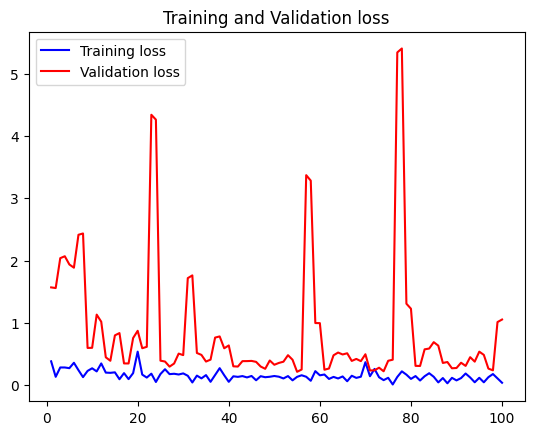

In [72]:
acc = history.history['binary_accuracy']
val_acc = history.history['val_binary_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

#Train and validation accuracy
plt.plot(epochs, acc, 'b', label='Training accurarcy')
plt.plot(epochs, val_acc, 'r', label='Validation accurarcy')
plt.title('Training and Validation accurarcy')
plt.legend()

plt.figure()
#Train and validation loss
plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and Validation loss')
plt.legend()

plt.show()

In [73]:
from sklearn.metrics import accuracy_score, confusion_matrix

preds = model.predict(X_test)

acc = accuracy_score(y_test, np.round(preds))*100
cm = confusion_matrix(y_test, np.round(preds))

tn, fp, fn, tp = cm.ravel()

print('CONFUSION MATRIX ------------------')
print(cm)

print('\n============TEST METRICS=============')
precision = tp/(tp+fp)*100
recall = tp/(tp+fn)*100
print('Accuracy: {}%'.format(acc))
print('Precision: {}%'.format(precision))
print('Recall: {}%'.format(recall))
print('F1-score: {}'.format(2*precision*recall/(precision+recall)))

print('\nTRAIN METRIC ----------------------')
print('Train acc: {}'.format(np.round((history.history['binary_accuracy'][-1])*100, 2)))

29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 128ms/step
CONFUSION MATRIX ------------------
[[ 65 213]
 [  2 639]]

============TEST METRICS=============
Accuracy: 76.6050054406964%
Precision: 75.0%
Recall: 99.68798751950078%
F1-score: 85.5994641661085

TRAIN METRIC ----------------------
Train acc: 100.0


<Axes: >

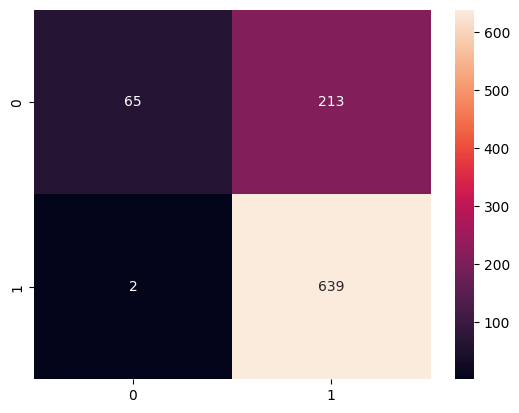

In [74]:
import seaborn as sns
sns.heatmap(cm, annot=True, fmt="d",)

AUC Score: 0.9430829751175659


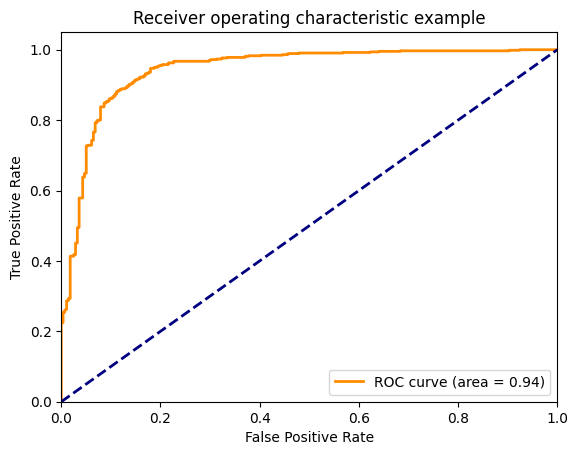

In [75]:
from sklearn.metrics import roc_curve,roc_auc_score
from sklearn.metrics import auc

fpr , tpr , thresholds = roc_curve ( y_test , preds)
auc_keras = auc(fpr, tpr)
print("AUC Score:",auc_keras)
plt.figure()
lw = 2
plt.plot(fpr, tpr, color='darkorange',
         lw=lw, label='ROC curve (area = %0.2f)' % auc_keras)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic example')
plt.legend(loc="lower right")
plt.show()